In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:
def interlace_prefix(list, prefix):
    
    with_prefix=[f'{prefix}{q}' for q in list]
    out= [None]*2*len(list)
    out[::2] = list
    out[1::2] = with_prefix

    return out

def interlace(list1, list2):
    
    out= [None]*2*len(list)
    out[::2] = list1
    out[1::2] = list2

    return out

def combine_subjects(df, codes_df):

    combined_df_data=[]

    for i, row in codes_df.iterrows():

        same_sub_mrns=[]

        for col in codes_df.columns:
            if col=='IncomingSite' or col=='Status':
                continue
            if np.isnan(row[col]):
                continue
            
            if int(row[col]) in df['MRN'].values and int(row[col]) not in same_sub_mrns:
                same_sub_mrns.append(int(row[col]))

        same_sub_df=df[df['MRN'].isin(same_sub_mrns)]

        if len(same_sub_mrns)==1:
            combined_df_data.append(same_sub_df.iloc[0].tolist()+[', '.join(str(mrn) for mrn in same_sub_mrns)])

        elif len(same_sub_mrns)>1:
            combined_row=[row['IncomingId']]
            for col in same_sub_df.columns[1:]:
                
                if 'explanation' in col.lower():
                    # print(same_sub_df[col])
                    expls=[val for val in same_sub_df[col] if type(val)==str]
                    combined_row.append('|'.join(expls))
                else:
                    combined_row.append(int(same_sub_df[col].max()))
            combined_df_data.append(combined_row+[', '.join(str(mrn) for mrn in same_sub_mrns)])


    out=pd.DataFrame(combined_df_data, columns=df.columns.tolist()+['other_matched_mrns'])
    out[df.columns.tolist()]=out[df.columns.tolist()]

    return out

def accuracy(conf_matrix):
    
    total_questions=sum([sum(row) for row in conf_matrix])
    good_answers=0
    for i in range(len(conf_matrix)):
        good_answers += conf_matrix[i][i]
    accuracy=good_answers/total_questions
    return accuracy

def sensitivity(conf_matrix, yes_col=2):
    total=sum(conf_matrix[yes_col])
    true_positives=conf_matrix[yes_col][yes_col]
    return true_positives/total

def specificity(conf_matrix, no_col=1):
    total=sum(conf_matrix[no_col])
    true_negatives=conf_matrix[no_col][no_col]
    return true_negatives/total

def precision(conf_matrix, yes_col=2):
    true_positives=conf_matrix[yes_col][yes_col]
    predicted_positives=sum([conf_matrix[i][yes_col] for i in range(len(conf_matrix))])
    return true_positives/predicted_positives

def combine_no_and_unknown(conf):
    output=np.array([conf[0]+conf[1], conf[2]])
    output=np.array([output[:,0]+output[:,1], output[:,2]]) 
    return output

def ignore_unknown(conf):
    return conf[1:,1:]

def confusion_matrix(truth_vector, pred_vector):
    matrix=[[0,0,0],
            [0,0,0],
            [0,0,0]]
    for truth, pred in zip(truth_vector,pred_vector):
        
        if type(pred)==str:
            print(f"Skipping string prediction: {pred}")
            continue
        
        matrix[int(truth)][int(pred)]+=1

    return np.array(matrix)

def statistical_df(confusion_matrix_dict,no_cols=1,yes_cols=2):
    
    confusion_matrix_dict['overall']=sum(list(confusion_matrix_dict.values()))

    out_df=pd.DataFrame.from_dict({q:accuracy(matrix) for q, matrix in confusion_matrix_dict.items()}, orient='index', columns=['accuracy'])
    
    out_df['specificity']=[specificity(matrix,no_cols) for q, matrix in confusion_matrix_dict.items()]
    out_df['sensitivity']=[sensitivity(matrix, yes_cols) for q, matrix in confusion_matrix_dict.items()]
    out_df['precision']=[precision(matrix, yes_cols) for q, matrix in confusion_matrix_dict.items()]

    out_df.reset_index(inplace=True, names='question')
    
    return out_df


In [3]:
sets=['bars','ccas','cnrs']
qs=json.load(open('/Users/rm026/Documents/code/reviewpyper/extraction_questions.json'))

qs_expls={}

for set in sets:
    for long_q, short_q in qs[set].items():
        qs_expls.update({long_q: short_q, f"EXPLANATION: {long_q}":f"explanation: {short_q}"})
    # qs_expls.update({f"EXPLANATION: {long_q}":f"Explanation: {short_q}" for long_q, short_q in qs[set].items()})


In [4]:
ai_expl=pd.read_csv("/Users/rm026/Documents/schmahmann/schmahmann_output_w_unknown/master_list.csv")
ai_expl.rename(columns=qs_expls, inplace=True)
ai_expl=ai_expl[['MRN']+list(qs_expls.values())]
ai_expl['similarities']=ai_expl['similarities'].map({2:1, 1:2, 0:0})
ai_expl=combine_subjects(ai_expl, pd.read_csv('/Users/rm026/Partners HealthCare Dropbox/Ross Macfadyen/raynor_network_mapping/metadata/schmahmann_rpdr_request/rm026_110525111627789405_Mrn.txt', sep='|'))
# ai_expl.drop(columns=['other_matched_mrns'], inplace=True)
ai_expl.to_csv('/Users/rm026/Documents/schmahmann/schmahmann_output_w_unknown/master_list_after_combination_similarities_fixed.csv', index=False)




In [5]:

abbrev_questions=list(qs['ccas'].values())
ai=ai_expl[ai_expl.columns.drop(list(ai_expl.filter(regex='EXPLANATION')))]
ai=ai[['MRN']+abbrev_questions]

gt=pd.read_csv("/Users/rm026/Documents/schmahmann/ground_truth_master_list_ccas.csv")
gt=gt[gt.columns.drop(list(gt.filter(regex='EXPLANATION')))]
gt.columns=['MRN']+abbrev_questions
gt['similarities']=gt['similarities'].map({2:1, 1:2, 0:0})
gt=combine_subjects(gt, pd.read_csv('/Users/rm026/Partners HealthCare Dropbox/Ross Macfadyen/raynor_network_mapping/metadata/schmahmann_rpdr_request/rm026_110525111627789405_Mrn.txt', sep='|'))
gt.drop(columns=['other_matched_mrns'], inplace=True)
ai.to_csv('/Users/rm026/Documents/schmahmann/schmahmann_ccas_ground_truth_combined_similarities_fixed.csv', index=False)

merged=pd.merge(ai,gt,on='MRN',suffixes=('_ai','_gt'))
merged

,MRN,semantic fluency_ai,phonemic fluency_ai,category switching_ai,verbal registration_ai,digit span_ai,cube draw_ai,cube copy_ai,similarities_ai,go-no go_ai,...,semantic fluency_gt,phonemic fluency_gt,category switching_gt,verbal registration_gt,digit span_gt,cube draw_gt,cube copy_gt,similarities_gt,go-no go_gt,affect_gt
0,6596307,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6890459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,6868827,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,7298779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,8231339,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,3699762,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
81,3815202,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
82,1175258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
83,1847722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [6]:
gt_w_expl=ai_expl
for col in gt.columns:
    gt_w_expl[col]=gt[col]
gt_w_expl.to_csv('/Users/rm026/Documents/schmahmann/schmahmann_ccas_ground_truth_with_explanations.csv', index=False)



In [7]:
conf_matrix=np.array([[0,0,0],
                    [0,0,0],
                    [0,0,0]])

for q in abbrev_questions:
    conf_matrix+=confusion_matrix(merged[q+'_gt'],merged[q+'_ai'])

conf_df=pd.DataFrame(conf_matrix,columns=['Predict unknown','Predict no','Predict yes'],index=['Truth unknown','Truth no','Truth yes'])
conf_df, accuracy(conf_matrix), accuracy(ignore_unknown(conf_matrix))

(               Predict unknown  Predict no  Predict yes
 Truth unknown              590          16            2
 Truth no                     6         138            2
 Truth yes                    1           1           94,
 np.float64(0.9670588235294117),
 np.float64(0.9872340425531915))

In [8]:
# no_unk=pd.read_csv("/Users/rm026/Documents/schmahmann/schmahmann_reviewpyper_dec_4/results/master_list.csv")
# no_unk=no_unk[['MRN']+ccas_questions]
# no_unk.columns=['MRN']+abbrev_questions
# no_unk=combine_subjects(no_unk, pd.read_csv('/Users/rm026/Partners HealthCare Dropbox/Ross Macfadyen/raynor_network_mapping/metadata/schmahmann_rpdr_request/rm026_110525111627789405_Mrn.txt', sep='|'))
# no_unk.drop(columns=['other_matched_mrns'], inplace=True)
# for question in abbrev_questions:
#     no_unk[question]=np.array(no_unk[question])+1
# merged_no_unk=pd.merge(no_unk,gt,on='MRN',suffixes=('_ai','_gt'))

# no_unk_matrix=np.array([[0,0,0],
#                         [0,0,0],
#                         [0,0,0]])
# for q in abbrev_questions:
#     no_unk_matrix+=confusion_matrix(merged_no_unk[q+'_gt'],merged_no_unk[q+'_ai'])

# no_unk_matrix=combine_no_and_unknown(no_unk_matrix)
# no_unk_matrix, accuracy(no_unk_matrix)

In [9]:
confs={q:confusion_matrix(merged[q+'_gt'],merged[q+'_ai']) for q in abbrev_questions}
resultsdf=statistical_df(confs)
resultsdf



,question,accuracy,specificity,sensitivity,precision
0,semantic fluency,0.952941,0.733333,1.000000,1.000000
1,phonemic fluency,0.964706,1.000000,0.916667,1.000000
2,category switching,0.976471,1.000000,1.000000,1.000000
3,verbal registration,0.964706,0.964286,0.800000,1.000000
4,digit span,0.905882,1.000000,1.000000,0.923077
5,cube draw,0.988235,1.000000,1.000000,1.000000
6,cube copy,0.964706,0.666667,1.000000,0.833333
7,similarities,0.964706,0.875000,1.000000,0.333333
8,go-no go,0.988235,1.000000,1.000000,1.000000
9,affect,1.000000,1.000000,1.000000,1.000000


In [18]:
sum(confs_ignore_unk.values())

array([[414,   6],
       [  3, 282]])

In [10]:
confs_ignore_unk={q:ignore_unknown(matrix) for q,matrix in confs.items()}
ignore_unk=statistical_df(confs_ignore_unk, 0,1)

confs_combo_unk={q:combine_no_and_unknown(matrix) for q, matrix in confs.items()}
combo_unk=statistical_df(confs_combo_unk, 0,1)

In [11]:
score_names=['accuracy','sensitivity','specificity','precision']

def plot_scores(df, yrange=(0.1,1.03),title='Schmahmann CCAS evaluation by question',
                filename=f'/Users/rm026/Documents/schmahmann/plots/stats_by_question.png'):
    
    colors=['Tomato', 'blue', 'green','purple','orange']

    plt.figure(figsize=(6,4))
    markers=['o','s','^', 'D']
    for i, score in enumerate(score_names):
        question_name=df['question'].str.title()
        plt.plot(question_name, df[score], marker=markers[i], color=colors[i])

    plt.title(title)
    plt.ylim(yrange)
    plt.xticks(rotation=45, ha='right')
    plt.legend([score.capitalize() for score in score_names])
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

def data_for_boxplot(confs, scores):

    confs=confs[confs['question']!='overall']
    out=[confs[score] for score in scores]
    return out

def boxplot(data,
              labels,
              title=None,
              filename='raincloud_plot.png',
              ylim=(-10,10),):

    fig, ax = plt.subplots(figsize=(6,4))
    
    # Create a list of colors for the boxplots based on the number of features you have
    boxplots_colors = ['darkred', 'blue', 'green','purple','orange']
    
    # Boxplot data
    bp = ax.boxplot(data, 
                    # notch=True,
                    patch_artist = True, 
                    vert = True,
                    showfliers=False,
                   medianprops={'linewidth':1.5},
                #    whiskerprops={'linewidth':2},
                   capprops={'linewidth':2}
                   )
    
    # Change to the desired color and add transparency
    for patch, color in zip(bp['boxes'], boxplots_colors):
        patch.set_facecolor(color)
        # patch.set_alpha(0.8)
    
    # Create a list of colors for the scatter plots based on the number of features you have
    scatter_colors = ['tomato', 'teal', 'lime', 'violet', 'tangerine']
    
    # Scatterplot data
    for idx, features in enumerate(data):
        # Add jitter effect so the features do not overlap on the y-axis
        y = np.full(len(features), idx + .65)
        idxs = np.arange(len(y))
        out = y.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.05, high=.05, size=len(idxs))
        y = out
        plt.scatter(y, features, c=scatter_colors[idx], edgecolors='black', alpha=.8)
    
    plt.xticks(np.arange(1,len(labels)+1,1), labels)  # Set text labels.
    # plt.ylabel('Damage Score', size='medium')
    plt.title(title)
    plt.ylim(ylim)
    plt.savefig(filename,bbox_inches='tight')
    plt.show()

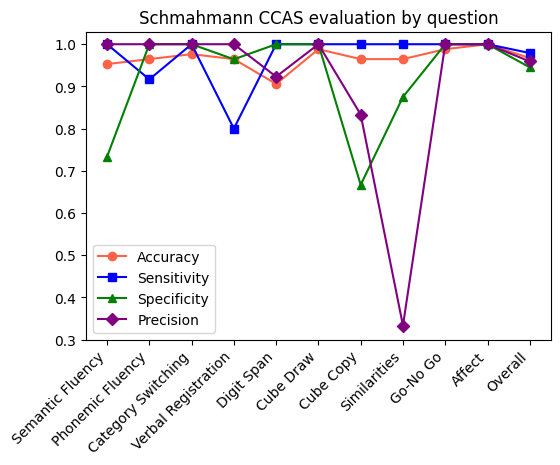

In [12]:
plot_scores(resultsdf, yrange=(.3,1.03), filename=f'/Users/rm026/Documents/schmahmann/plots/ccas/stats_by_question.png')

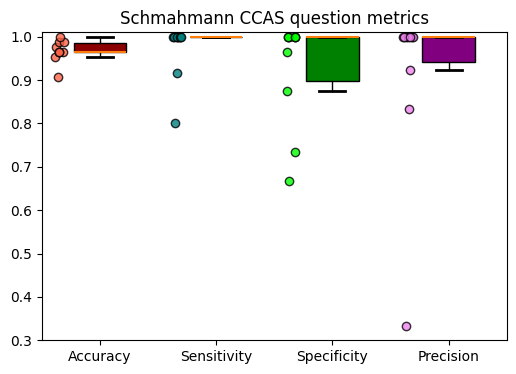

In [13]:

boxplot(data_for_boxplot(resultsdf, score_names), 
        labels=[score.title() for score in score_names], 
        title='Schmahmann CCAS question metrics',
        filename='/Users/rm026/Documents/schmahmann/plots/ccas/schmahmann_metrics_boxplot.png', ylim=(.3,1.01))

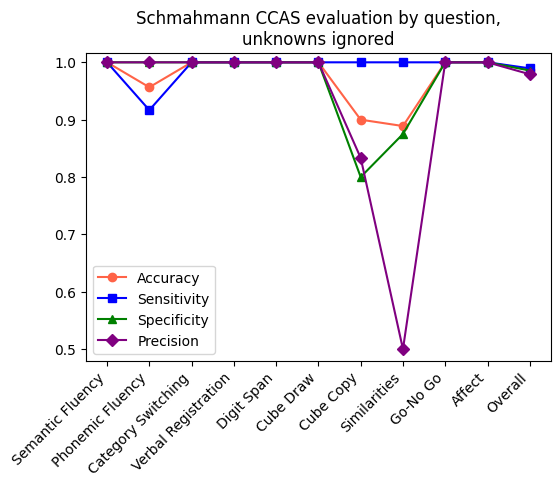

In [14]:
plot_scores(ignore_unk, yrange=(.48,1.017),
            title='Schmahmann CCAS evaluation by question,\nunknowns ignored', 
            filename=f'/Users/rm026/Documents/schmahmann/plots/ccas/stats_by_question_unk_removed.png')

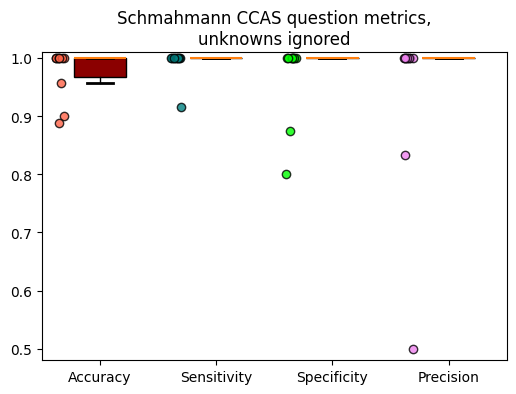

In [15]:
boxplot(data_for_boxplot(ignore_unk, score_names),
        labels=[score.title() for score in score_names], 
        title='Schmahmann CCAS question metrics,\nunknowns ignored',
        filename='/Users/rm026/Documents/schmahmann/plots/ccas/schmahmann_metrics_ignore_unknown_boxplot.png', ylim=(.48,1.01))

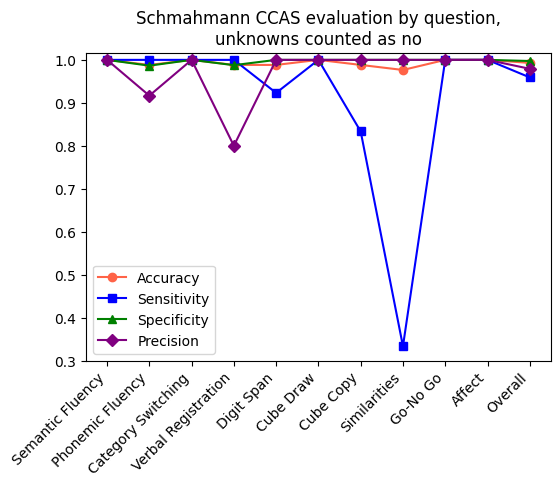

In [16]:
plot_scores(combo_unk, yrange=(0.3,1.017),
            title='Schmahmann CCAS evaluation by question,\nunknowns counted as no', 
            filename=f'/Users/rm026/Documents/schmahmann/plots/ccas/stats_by_question_unk_combo.png')

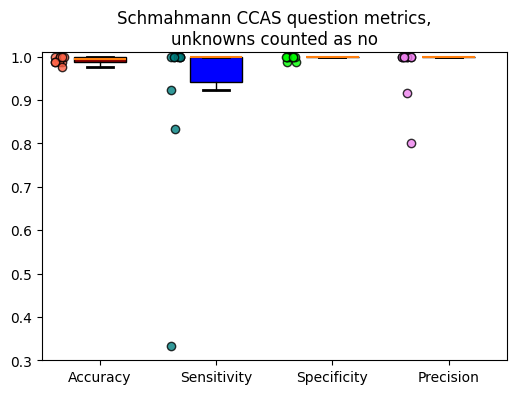

In [17]:
boxplot(data_for_boxplot(combo_unk, score_names),
        labels=[score.title() for score in score_names], 
        title='Schmahmann CCAS question metrics,\nunknowns counted as no',
        filename='/Users/rm026/Documents/schmahmann/plots/ccas/schmahmann_metrics_combo_unknown_boxplot.png', ylim=(.3,1.01))